In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[3]))
from utils.helpers import load_data

from scipy.stats import spearmanr, pearsonr

In [3]:
# Define consistent color palette for gender comparison
COLOR_MALE = '#4A90E2'        # Bright blue for male students
COLOR_FEMALE = '#E85A9B'      # Pink for female students
COLOR_COMBINED = '#6B8CAE'    # Steel blue for combined data
COLOR_BOXPLOT = '#2C3E50'     # Dark blue-grey for boxplots

# Time analysis specific colors
COLOR_EXPECTED = '#87CEEB'    # Light blue for expected time
COLOR_FAST = '#FFD700'        # Yellow for faster than expected
COLOR_SLOW = '#FF4444'        # Red for slower than expected

# Gender color mapping
GENDER_COLORS = {
    'M': COLOR_MALE,
    'F': COLOR_FEMALE,
    'Male': COLOR_MALE,
    'Female': COLOR_FEMALE
}

# Time Analysis - Gender Comparison

Detailed analysis of time during the exam comparing male and female students. Expected time vs. time taken task by task.

**Analysis focuses on:**
- Gender differences in time distribution and patterns
- Expected vs. actual time per task (by gender)
- Time deviations from expected values (by gender)
- Rapid guessing patterns (by gender)
- Temporal progression and fatigue effects (by gender)

**Note:** This analysis only includes students without extra or incident time.

## 1. Data Loading

In [4]:
df = load_data("../data/cleaned_data/IN2120_2024_cleaned_data.csv")
df.head()

Data loaded successfully from ../data/cleaned_data/IN2120_2024_cleaned_data.csv


,exam_start_time,exam_end_time,extra_time_mins,incident_time_mins,gender,student_id,final_grade_date,final_grade,max_question_score,question_number,question_title,question_duration_sec,auto_score_per_question,candidate_response_code,candidate_response_text,total_score
0,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_1370871167225,konfidensialitet,67.5
1,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_IA17313295674742d674d25-c722-4a92...,tilgjengelighet,67.5
2,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,3,1.1,Generelle sikkerhetsmålsettinger,53,3.0,simpleChoice_IA173132962912484243f1a-833f-47fb...,integritet,67.5
3,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,2,1.2,Oversettelse,30,2.0,simpleAssociableChoice_IA173100234618194d062e4...,simpleAssociableChoice_IA173100234618194d062e4...,67.5
4,2024-11-25 08:00:01,2024-11-25 10:29:42,0,0,M,256,2024-12-18T10:19:50Z,B,2,1.2,Oversettelse,30,2.0,simpleAssociableChoice_1373281683440 simpleAss...,simpleAssociableChoice_1373281683440 simpleAss...,67.5


## 2. Data Preparation

In [5]:
df_time = df.groupby(['student_id', 'question_number']).agg({
    'gender': 'first',
    'max_question_score': 'first',
    'auto_score_per_question': 'first',
    'question_duration_sec': 'first',
    'exam_start_time': 'first',
    'exam_end_time': 'first',
    'extra_time_mins': 'first',
    'incident_time_mins': 'first',
    'total_score': 'first'
}).reset_index()

df_time['time_taken_exam_min'] = round((pd.to_datetime(df_time['exam_end_time']) - pd.to_datetime(df_time['exam_start_time'])).dt.total_seconds() / 60, 2)
df_time = df_time.drop(columns=['exam_start_time', 'exam_end_time'])

df_time['expected_time_per_question_sec'] = 144 * df_time['max_question_score']  # 144 sec (2.4 minutes) per point

df_time.head()

,student_id,question_number,gender,max_question_score,auto_score_per_question,question_duration_sec,extra_time_mins,incident_time_mins,total_score,time_taken_exam_min,expected_time_per_question_sec
0,1,1.10,M,3,3.0,38,0,0,45.0,105.57,432
1,1,1.11,M,1,1.0,49,0,0,45.0,105.57,144
2,1,1.12,M,3,1.0,181,0,0,45.0,105.57,432
3,1,1.13,M,3,2.0,31,0,0,45.0,105.57,432
4,1,1.20,M,2,2.0,31,0,0,45.0,105.57,288


## 3. Data Exploration

In [6]:
extra_time_students_data = df_time[(df_time['extra_time_mins'] != 0) | (df_time['incident_time_mins'] != 0)]

extra_time_students_count = extra_time_students_data.groupby('student_id').agg({
    'extra_time_mins': 'first',
    'incident_time_mins': 'first'
}).reset_index()

counter1 = sum(1 for i in extra_time_students_count['extra_time_mins'] if i != 0)
counter2 = sum(1 for i in extra_time_students_count['incident_time_mins'] if i != 0)

print(f"There are {counter1} students with extra_time_mins (given before the exam).")
print(f"There are {counter2} students with incident_time_mins (given during the exam).")

There are 0 students with extra_time_mins (given before the exam).
There are 1 students with incident_time_mins (given during the exam).


In [7]:
# Gender breakdown
gender_counts = df_time.groupby('gender')['student_id'].nunique()
print(f"\nTotal students remaining: {df_time['student_id'].nunique()}")
print(f"Male students: {gender_counts.get('M', 0)}")
print(f"Female students: {gender_counts.get('F', 0)}")


Total students remaining: 367
Male students: 226
Female students: 141


In [8]:
# Time statistics by gender
print("\n=== TIME STATISTICS BY GENDER ===")
time_stats_by_gender = df_time.groupby('gender')['time_taken_exam_min'].describe()
print(time_stats_by_gender)


=== TIME STATISTICS BY GENDER ===
         count        mean        std    min     25%      50%     75%     max
gender                                                                       
F       5217.0  152.815674  49.659334  59.07  114.28  145.400  187.68  270.53
M       8362.0  130.816947  47.340465  44.47   94.45  120.065  165.73  240.05


## 5. Expected vs Actual Time Per Task (By Gender)

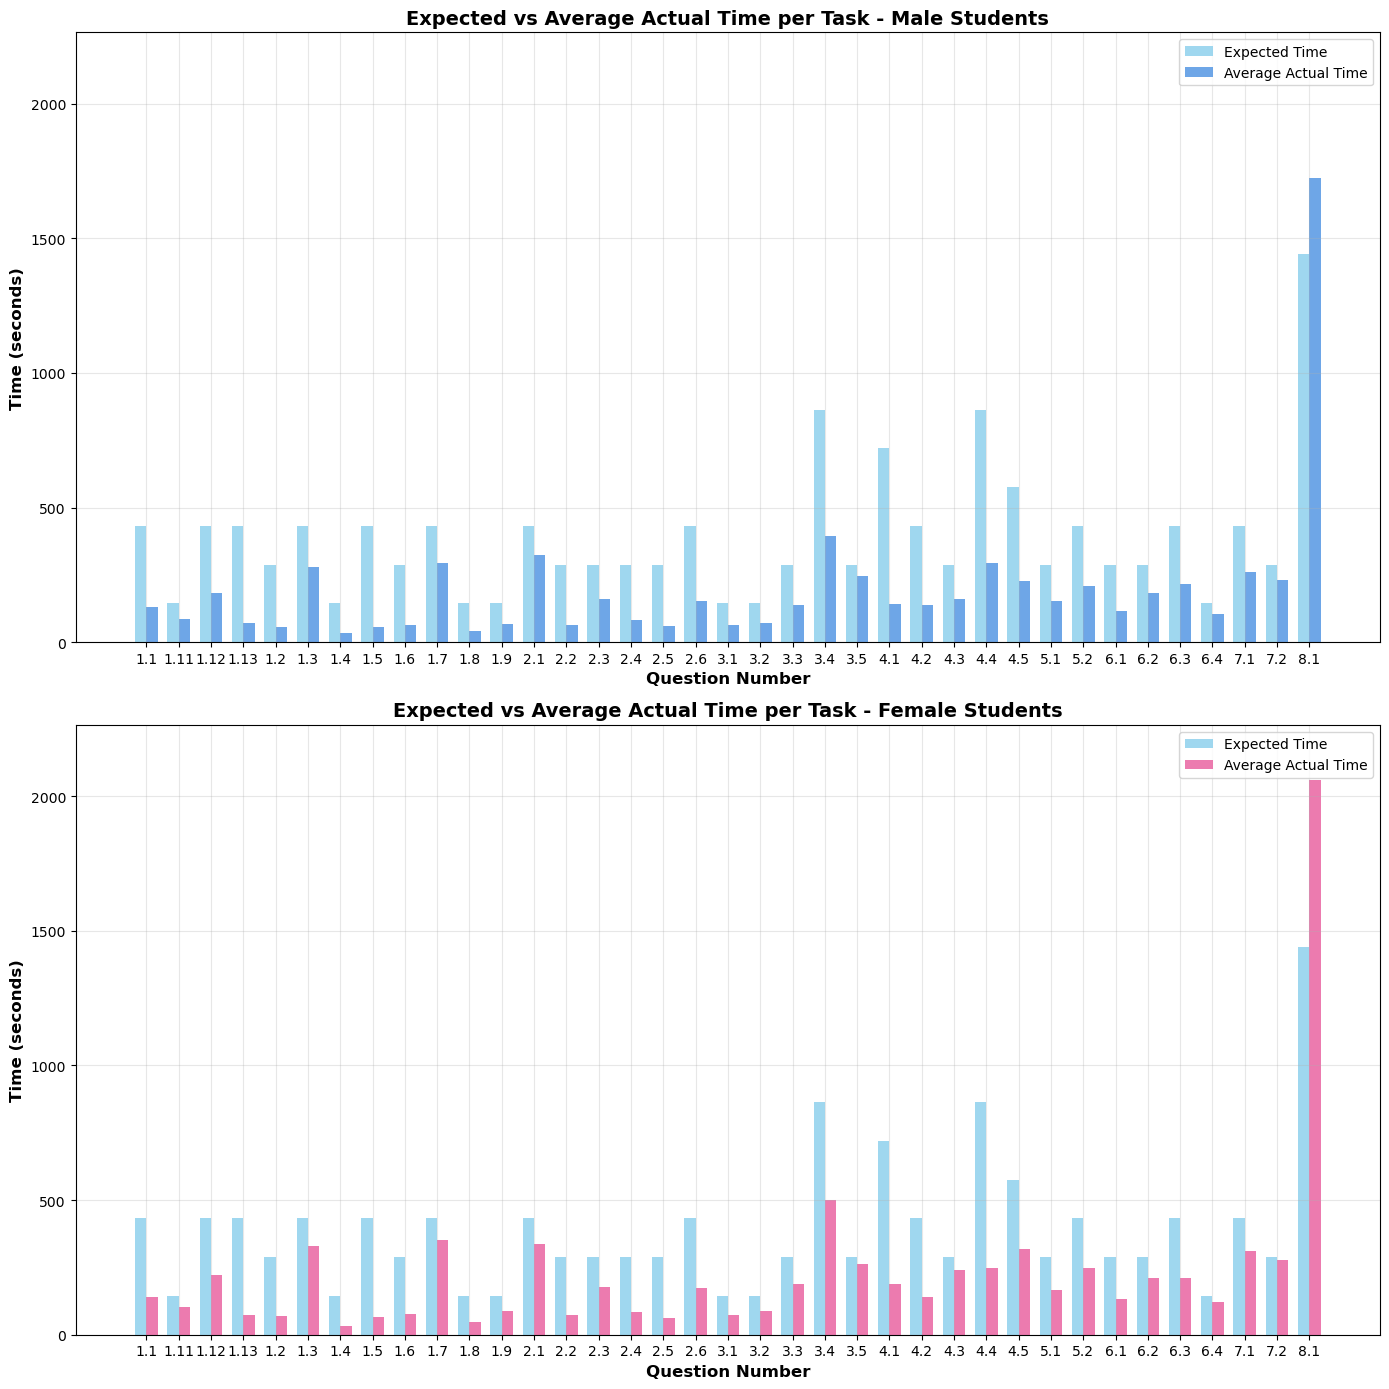

In [9]:
# Calculate time by task for each gender
time_by_task_male = df_time[df_time['gender'] == 'M'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

time_by_task_female = df_time[df_time['gender'] == 'F'].groupby('question_number').agg({
    'expected_time_per_question_sec': 'first',
    'question_duration_sec': 'mean'
}).reset_index()

# Determine maximum y-axis value for consistent scaling
max_expected = max(time_by_task_male['expected_time_per_question_sec'].max(),
                   time_by_task_female['expected_time_per_question_sec'].max())
max_actual = max(time_by_task_male['question_duration_sec'].max(),
                 time_by_task_female['question_duration_sec'].max())
y_max = max(max_expected, max_actual) * 1.1

# Create plots
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

width = 0.35

# Plot 1: Male students
x_male = time_by_task_male['question_number']
x_pos_male = range(len(x_male))

bars1 = axes[0].bar([i - width/2 for i in x_pos_male], time_by_task_male['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars2 = axes[0].bar([i + width/2 for i in x_pos_male], time_by_task_male['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_MALE, alpha=0.8)

axes[0].set_xlabel('Question Number', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Expected vs Average Actual Time per Task - Male Students', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos_male)
axes[0].set_xticklabels(x_male)
axes[0].set_ylim(0, y_max)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Female students
x_female = time_by_task_female['question_number']
x_pos_female = range(len(x_female))

bars3 = axes[1].bar([i - width/2 for i in x_pos_female], time_by_task_female['expected_time_per_question_sec'], 
                   width, label='Expected Time', color='#87CEEB', alpha=0.8)
bars4 = axes[1].bar([i + width/2 for i in x_pos_female], time_by_task_female['question_duration_sec'], 
                   width, label='Average Actual Time', color=COLOR_FEMALE, alpha=0.8)

axes[1].set_xlabel('Question Number', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Expected vs Average Actual Time per Task - Female Students', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos_female)
axes[1].set_xticklabels(x_female)
axes[1].set_ylim(0, y_max)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Time Deviation Analysis (By Gender)

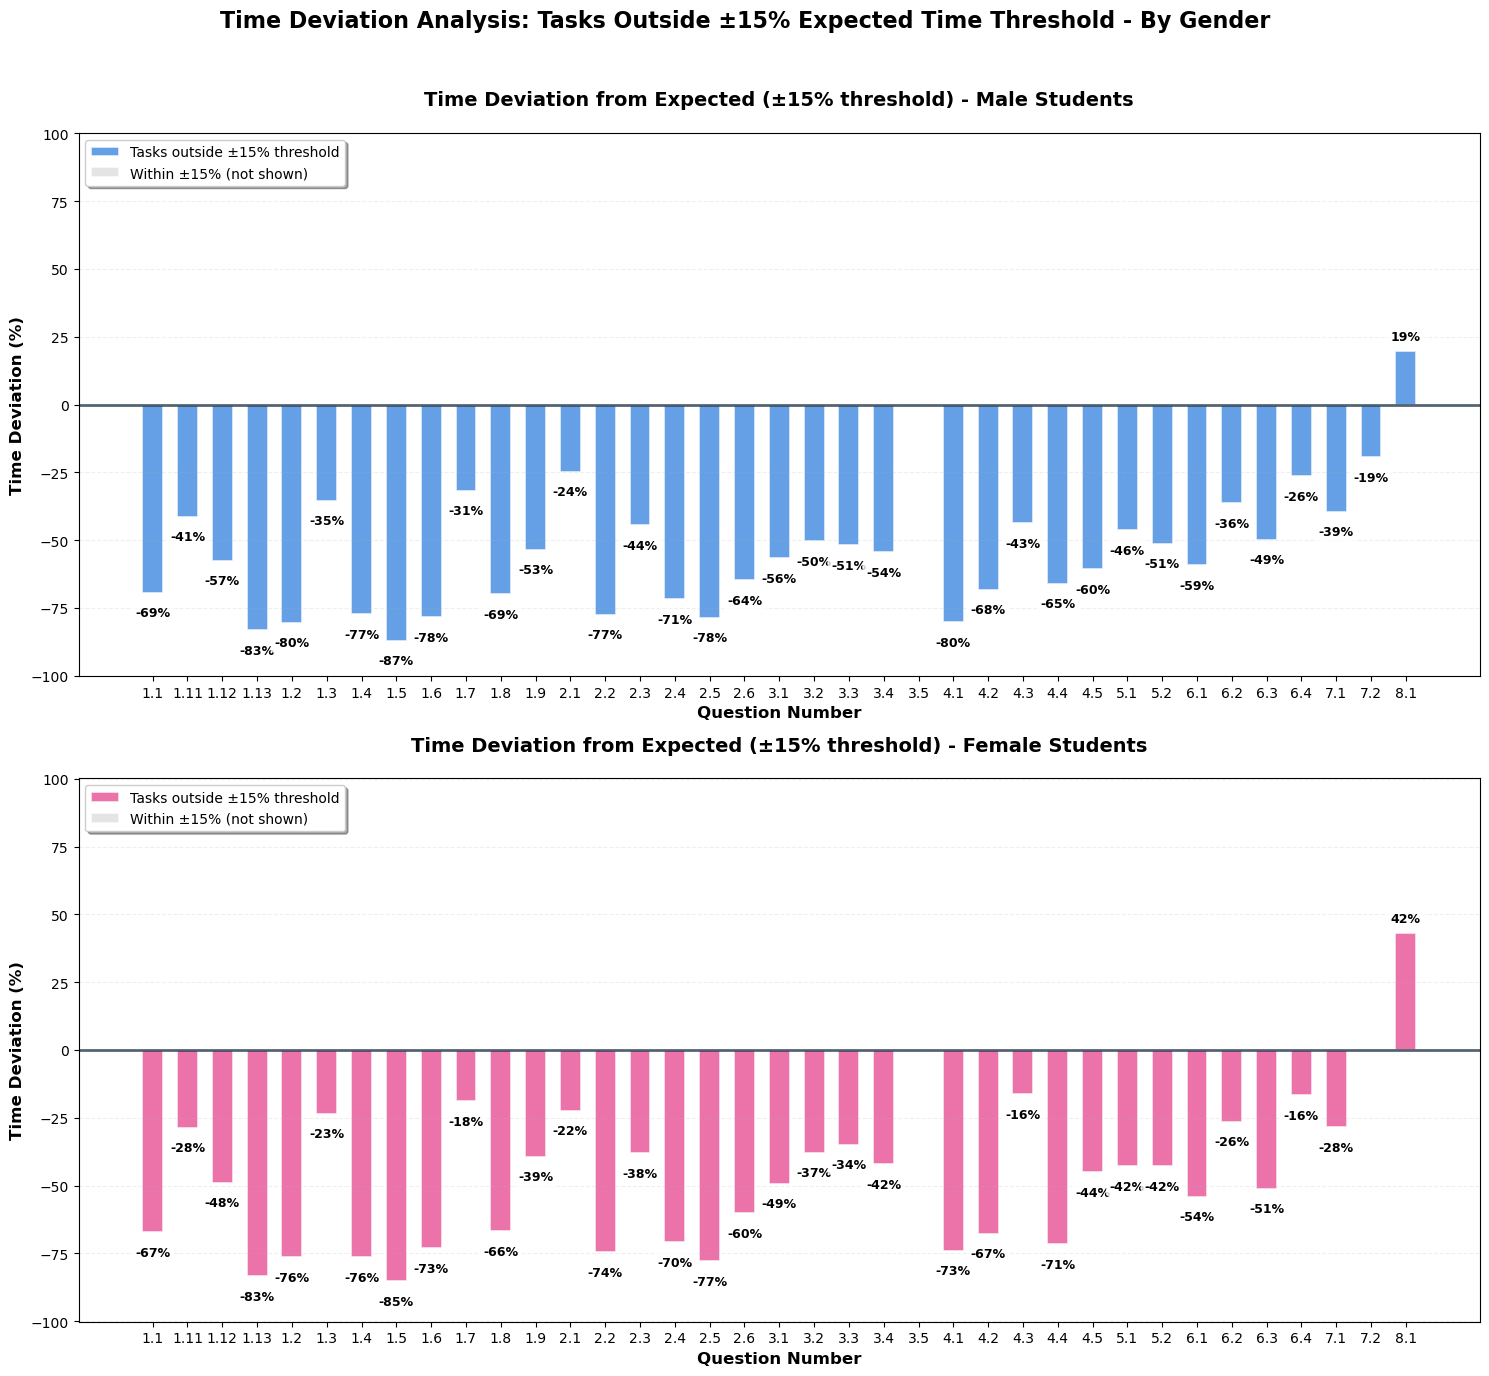


=== TIME DEVIATION SUMMARY ===

Male Students:
  Tasks outside ±15% threshold: 36/37 (97.3%)
  Tasks taking longer than expected (>15%): 1
  Tasks taking less time than expected (<-15%): 35
    Slowest tasks: 8.1
    Fastest tasks: 1.5, 1.13, 1.2

Female Students:
  Tasks outside ±15% threshold: 35/37 (94.6%)
  Tasks taking longer than expected (>15%): 1
  Tasks taking less time than expected (<-15%): 34
    Slowest tasks: 8.1
    Fastest tasks: 1.5, 1.13, 2.5


In [10]:
# Time deviation analysis by gender
def calculate_time_deviations(data):
    """Calculate time deviations from expected time"""
    time_by_task = data.groupby('question_number').agg({
        'expected_time_per_question_sec': 'first',
        'question_duration_sec': 'mean'
    }).reset_index()
    
    time_by_task['deviation_pct'] = ((time_by_task['question_duration_sec'] - time_by_task['expected_time_per_question_sec']) / 
                                    time_by_task['expected_time_per_question_sec']) * 100
    
    time_by_task['deviation_pct_filtered'] = time_by_task['deviation_pct'].where(
        (time_by_task['deviation_pct'] < -15) | (time_by_task['deviation_pct'] > 15), 0
    )
    
    return time_by_task

deviation_male = calculate_time_deviations(df_time[df_time['gender'] == 'M'])
deviation_female = calculate_time_deviations(df_time[df_time['gender'] == 'F'])

# Calculate global y-axis limits
all_deviations = list(deviation_male['deviation_pct_filtered']) + list(deviation_female['deviation_pct_filtered'])
max_abs_deviation = max(abs(min(all_deviations)), abs(max(all_deviations)))
y_limit = max_abs_deviation * 1.15

# Create deviation plots
fig, axes = plt.subplots(2, 1, figsize=(15, 14))
fig.suptitle('Time Deviation Analysis: Tasks Outside ±15% Expected Time Threshold - By Gender', 
             fontsize=16, fontweight='bold', y=0.98)

def create_deviation_plot(ax, data, title, bar_color, y_limit):
    x = data['question_number']
    y = data['deviation_pct_filtered']
    x_pos = range(len(x))
    
    colors = [bar_color if val != 0 else '#E0E0E0' for val in y]
    bars = ax.bar(x_pos, y, width=0.6, color=colors, alpha=0.85, 
                  edgecolor='white', linewidth=1.2)
    
    ax.axhline(y=0, color='#2C3E50', linestyle='-', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Question Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Time Deviation (%)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.2, axis='y', linestyle='--')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x, fontsize=10, rotation=0)
    ax.set_ylim(-y_limit, y_limit)
    
    # Add value labels
    for bar, value in zip(bars, y):
        if abs(value) > 1:
            height = bar.get_height()
            label_y = height + (3 if height > 0 else -5)
            ax.text(bar.get_x() + bar.get_width()/2., label_y,
                   f'{int(height)}%', ha='center', 
                   va='bottom' if height > 0 else 'top',
                   fontsize=9, fontweight='bold', 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none'))
    
    return ax

# Plot 1: Male students
create_deviation_plot(axes[0], deviation_male,
                     'Time Deviation from Expected (±15% threshold) - Male Students',
                     COLOR_MALE, y_limit)

from matplotlib.patches import Patch
legend_male = [
    Patch(facecolor=COLOR_MALE, alpha=0.85, edgecolor='white', linewidth=1.2, label='Tasks outside ±15% threshold'),
    Patch(facecolor='#E0E0E0', alpha=0.85, edgecolor='white', linewidth=1.2, label='Within ±15% (not shown)')
]
axes[0].legend(handles=legend_male, loc='upper left', frameon=True, 
              fancybox=True, shadow=True, fontsize=10)

# Plot 2: Female students
create_deviation_plot(axes[1], deviation_female,
                     'Time Deviation from Expected (±15% threshold) - Female Students',
                     COLOR_FEMALE, y_limit)

legend_female = [
    Patch(facecolor=COLOR_FEMALE, alpha=0.85, edgecolor='white', linewidth=1.2, label='Tasks outside ±15% threshold'),
    Patch(facecolor='#E0E0E0', alpha=0.85, edgecolor='white', linewidth=1.2, label='Within ±15% (not shown)')
]
axes[1].legend(handles=legend_female, loc='upper left', frameon=True, 
              fancybox=True, shadow=True, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print summary statistics
print("\n=== TIME DEVIATION SUMMARY ===")
for name, data in [("Male", deviation_male), ("Female", deviation_female)]:
    outside_threshold = data[abs(data['deviation_pct']) > 15]
    slower_tasks = data[data['deviation_pct'] > 15]
    faster_tasks = data[data['deviation_pct'] < -15]
    
    print(f"\n{name} Students:")
    print(f"  Tasks outside ±15% threshold: {len(outside_threshold)}/{len(data)} ({len(outside_threshold)/len(data)*100:.1f}%)")
    print(f"  Tasks taking longer than expected (>15%): {len(slower_tasks)}")
    print(f"  Tasks taking less time than expected (<-15%): {len(faster_tasks)}")
    
    if len(slower_tasks) > 0:
        print(f"    Slowest tasks: {', '.join(map(str, slower_tasks.nlargest(3, 'deviation_pct')['question_number'].tolist()))}")
    if len(faster_tasks) > 0:
        print(f"    Fastest tasks: {', '.join(map(str, faster_tasks.nsmallest(3, 'deviation_pct')['question_number'].tolist()))}")

## 7. Rapid Guessing Patterns (By Gender)

In [11]:
def analyze_rapid_guessing_by_gender(df, rapid_guess_threshold=15):
    """Analyze rapid guessing patterns by gender"""
    df_rg = df.copy()
    df_rg['is_rapid_guess'] = df_rg['question_duration_sec'] < rapid_guess_threshold
    
    # Student-level statistics by gender
    student_rapid_stats = df_rg.groupby(['student_id', 'gender']).agg({
        'is_rapid_guess': ['sum', 'count', 'mean'],
        'total_score': 'first'
    }).reset_index()
    
    student_rapid_stats.columns = ['student_id', 'gender', 'rapid_guess_count', 'total_questions', 
                                   'rapid_guess_percentage', 'total_score']
    student_rapid_stats['rapid_guess_percentage'] *= 100
    
    # Gender-level statistics
    gender_stats = student_rapid_stats.groupby('gender').agg({
        'rapid_guess_percentage': ['mean', 'std'],
        'total_score': 'mean'
    }).round(2)
    
    # Correlations by gender
    correlations = {}
    for gender_code in ['M', 'F']:
        gender_data = student_rapid_stats[student_rapid_stats['gender'] == gender_code]
        if len(gender_data) > 1:
            pearson_corr, pearson_p = pearsonr(gender_data['rapid_guess_percentage'], 
                                              gender_data['total_score'])
            spearman_corr, spearman_p = spearmanr(gender_data['rapid_guess_percentage'], 
                                                 gender_data['total_score'])
            correlations[gender_code] = {
                'pearson': {'correlation': pearson_corr, 'p_value': pearson_p},
                'spearman': {'correlation': spearman_corr, 'p_value': spearman_p}
            }
    
    # Question-level statistics
    question_rapid_stats = df_rg.groupby('question_number').agg({
        'is_rapid_guess': ['sum', 'count', 'mean']
    }).reset_index()
    
    question_rapid_stats.columns = ['question_number', 'rapid_guess_count', 'total_attempts', 'rapid_guess_rate']
    question_rapid_stats['rapid_guess_rate'] *= 100
    
    results = {
        'student_stats': student_rapid_stats,
        'gender_stats': gender_stats,
        'question_stats': question_rapid_stats,
        'correlations': correlations,
        'threshold': rapid_guess_threshold
    }
    
    # Print summary
    print(f"=== RAPID GUESSING ANALYSIS BY GENDER (Threshold: <{rapid_guess_threshold} seconds) ===")
    print(f"Overall rapid guess rate: {df_rg['is_rapid_guess'].mean()*100:.1f}%")
    
    print("\n--- GENDER COMPARISON ---")
    for gender_label, gender_code in [('Male', 'M'), ('Female', 'F')]:
        gender_data = student_rapid_stats[student_rapid_stats['gender'] == gender_code]
        if len(gender_data) > 0:
            print(f"\n{gender_label} students:")
            print(f"  Average rapid guess percentage: {gender_data['rapid_guess_percentage'].mean():.1f}%")
            print(f"  Students with >50% rapid guesses: {len(gender_data[gender_data['rapid_guess_percentage'] > 50])}")
            print(f"  Students with 0% rapid guesses: {len(gender_data[gender_data['rapid_guess_percentage'] == 0])}")
            
            if gender_code in correlations:
                corr_data = correlations[gender_code]
                print(f"  Pearson correlation: r = {corr_data['pearson']['correlation']:.3f}, p = {corr_data['pearson']['p_value']:.3f}")
                print(f"  Spearman correlation: ρ = {corr_data['spearman']['correlation']:.3f}, p = {corr_data['spearman']['p_value']:.3f}")
    
    return results

rapid_guess_results = analyze_rapid_guessing_by_gender(df_time, rapid_guess_threshold=15)

=== RAPID GUESSING ANALYSIS BY GENDER (Threshold: <15 seconds) ===
Overall rapid guess rate: 1.4%

--- GENDER COMPARISON ---

Male students:
  Average rapid guess percentage: 1.7%
  Students with >50% rapid guesses: 0
  Students with 0% rapid guesses: 140
  Pearson correlation: r = -0.128, p = 0.054
  Spearman correlation: ρ = -0.094, p = 0.157

Female students:
  Average rapid guess percentage: 0.9%
  Students with >50% rapid guesses: 0
  Students with 0% rapid guesses: 106
  Pearson correlation: r = -0.045, p = 0.593
  Spearman correlation: ρ = -0.033, p = 0.699


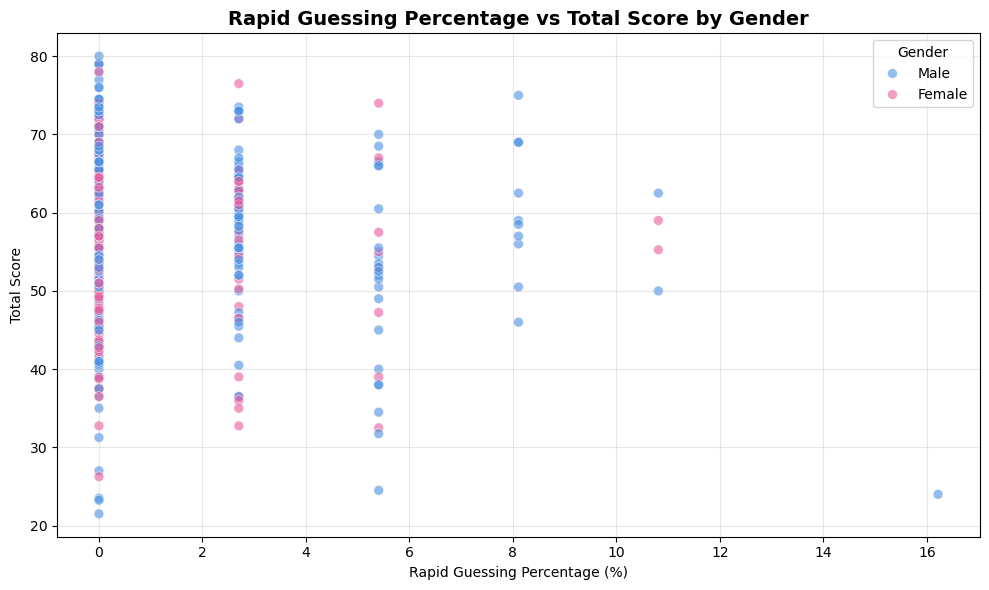

In [12]:
# Visualize rapid guessing vs scores by gender
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rapid_guess_results['student_stats'],
                x='rapid_guess_percentage', 
                y='total_score',
                hue='gender',
                palette=GENDER_COLORS,
                alpha=0.6, s=50)
plt.title('Rapid Guessing Percentage vs Total Score by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Rapid Guessing Percentage (%)')
plt.ylabel('Total Score')

# Update legend labels
handles, labels = plt.gca().get_legend_handles_labels()
label_mapping = {'F': 'Female', 'M': 'Male'}
new_labels = [label_mapping.get(label, label) for label in labels]
plt.legend(handles, new_labels, title='Gender')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Temporal Progression Analysis (By Gender)

In [13]:
# Prepare temporal progression data by gender
temporal_male = df_time[df_time['gender'] == 'M'].groupby('question_number').agg({
    'question_duration_sec': ['mean', 'median'],
    'auto_score_per_question': 'mean',
    'max_question_score': 'first'
}).reset_index()
temporal_male.columns = ['question_number', 'mean_time', 'median_time', 'mean_score', 'max_score']
temporal_male['accuracy_rate'] = (temporal_male['mean_score'] / temporal_male['max_score']) * 100

temporal_female = df_time[df_time['gender'] == 'F'].groupby('question_number').agg({
    'question_duration_sec': ['mean', 'median'],
    'auto_score_per_question': 'mean',
    'max_question_score': 'first'
}).reset_index()
temporal_female.columns = ['question_number', 'mean_time', 'median_time', 'mean_score', 'max_score']
temporal_female['accuracy_rate'] = (temporal_female['mean_score'] / temporal_female['max_score']) * 100

# Expected time
temporal_expected = df_time.groupby('question_number')['expected_time_per_question_sec'].first().reset_index()

print("=== TEMPORAL PROGRESSION DATA BY GENDER ===")
print(f"Male - Questions analyzed: {len(temporal_male)}")
print(f"Female - Questions analyzed: {len(temporal_female)}")

=== TEMPORAL PROGRESSION DATA BY GENDER ===
Male - Questions analyzed: 37
Female - Questions analyzed: 37


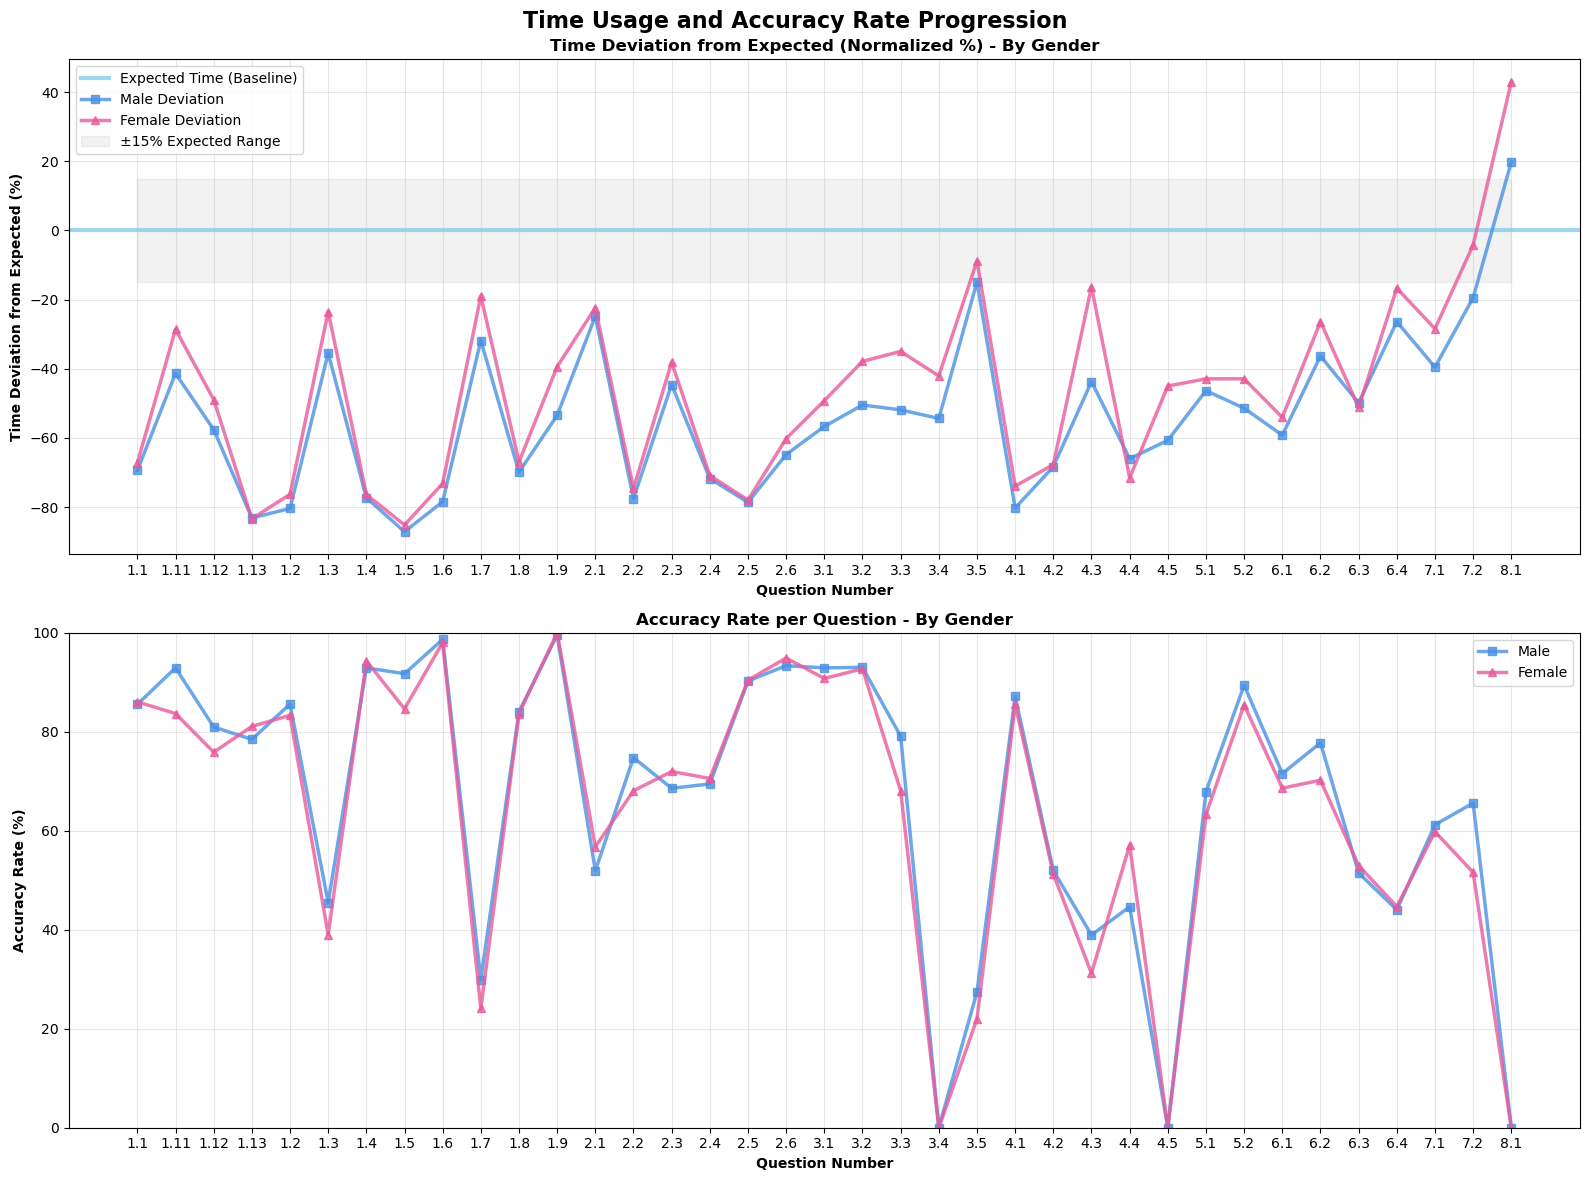

In [14]:
# Time progression visualization by gender
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Time Usage and Accuracy Rate Progression', fontsize=16, fontweight='bold')

x_positions = range(len(temporal_expected))

# Plot 1: Time Deviation from Expected
male_deviation_pct = ((temporal_male['mean_time'] - temporal_expected['expected_time_per_question_sec']) / 
                      temporal_expected['expected_time_per_question_sec']) * 100
female_deviation_pct = ((temporal_female['mean_time'] - temporal_expected['expected_time_per_question_sec']) / 
                        temporal_expected['expected_time_per_question_sec']) * 100

axes[0].axhline(y=0, linestyle='-', linewidth=3, color=COLOR_EXPECTED, label='Expected Time (Baseline)', alpha=0.8)
axes[0].plot(x_positions, male_deviation_pct, marker='s', linewidth=2.5, markersize=6, 
            color=COLOR_MALE, label='Male Deviation', alpha=0.8)
axes[0].plot(x_positions, female_deviation_pct, marker='^', linewidth=2.5, markersize=6, 
            color=COLOR_FEMALE, label='Female Deviation', alpha=0.8)

axes[0].fill_between(x_positions, [-15] * len(x_positions), [15] * len(x_positions), 
                     alpha=0.1, color='gray', label='±15% Expected Range')

axes[0].set_xlabel('Question Number', fontweight='bold')
axes[0].set_ylabel('Time Deviation from Expected (%)', fontweight='bold')
axes[0].set_title('Time Deviation from Expected (Normalized %) - By Gender', fontweight='bold')
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(temporal_expected['question_number'])
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Accuracy Rate Progression
axes[1].plot(x_positions, temporal_male['accuracy_rate'], marker='s', linewidth=2.5, markersize=6, 
            color=COLOR_MALE, label='Male', alpha=0.8)
axes[1].plot(x_positions, temporal_female['accuracy_rate'], marker='^', linewidth=2.5, markersize=6, 
            color=COLOR_FEMALE, label='Female', alpha=0.8)

axes[1].set_xlabel('Question Number', fontweight='bold')
axes[1].set_ylabel('Accuracy Rate (%)', fontweight='bold')
axes[1].set_title('Accuracy Rate per Question - By Gender', fontweight='bold')
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(temporal_expected['question_number'])
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()